# Step 5: Fine-Tuning EoMT with LoRA — Three Experiments

All three experiments use `MaskClassificationLoRA` and the same LoRA config.
The only difference between them is which parameters have `requires_grad=True`.
`configure_optimizers` adapts automatically: it filters by `requires_grad` and
routes whatever is trainable into the right param groups for
`TwoStageWarmupPolySchedule` + LLRD.

| Experiment | Trainable |
|---|---|
| 1 — head only | prediction head; all LoRA adapters frozen |
| 2 — decoder LoRA | prediction head + LoRA adapters in blocks 9–11 |
| 3 — full LoRA | prediction head + LoRA adapters in all 12 blocks (LLRD) |

In [1]:
!pip install lightning gitignore_parser peft > /dev/null
!pip install -U "torchao>=0.16.0" > /dev/null
!pip install -U 'jsonargparse[signatures]>=4.27.7' > /dev/null
!pip install wandb > /dev/null

In [2]:
from google.colab import drive, userdata
import os, sys, json, yaml, glob, shutil
import torch
import torch.nn.functional as F
import wandb
from tqdm import tqdm
from lightning import seed_everything
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import WandbLogger

In [3]:
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

project_root = '/content/drive/MyDrive/FundGitHubProject'
eomt_folder  = project_root + '/eomt'

if not os.path.exists('/content/ProjectFolder'):
    os.symlink(project_root, '/content/ProjectFolder')

os.chdir(project_root)
for p in [project_root, eomt_folder]:
    if p not in sys.path:
        sys.path.insert(0, p)

Mounted at /content/drive


In [4]:
from eval.iouEval import iouEval
from training.mask_classification_panoptic import MaskClassificationPanoptic
from training.mask_classification_lora import MaskClassificationLoRA
from models.eomt import EoMT
from models.vit import ViT
from datasets.cityscapes_semantic import CityscapesSemantic
import torch.serialization
from peft import PeftModel
from peft.tuners.lora import LoraModel

# Modern PyTorch Safe Loading Fix
torch.serialization.add_safe_globals([EoMT, ViT, MaskClassificationLoRA, PeftModel, LoraModel])

seed_everything(0, verbose=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [5]:
import time

drive_data = os.path.join(eomt_folder, 'data')
local_data = '/content/cityscapes_data'
os.makedirs(local_data, exist_ok=True)

# Copy only the two zip files that the dataset reads — much faster than copytree.
# Reads then hit local NVMe SSD (~1 GB/s) instead of Drive FUSE (~50 MB/s),
# cutting epoch time from ~40 min down to ~3-5 min.
for fname in ['leftImg8bit_trainvaltest.zip', 'gtFine_trainvaltest.zip']:
    src = os.path.join(drive_data, fname)
    dst = os.path.join(local_data, fname)
    if not os.path.exists(dst):
        print(f"Copying {fname} to local SSD...")
        t = time.time()
        shutil.copy(src, dst)
        print(f"  Done in {time.time()-t:.0f}s ({os.path.getsize(dst)/1e9:.1f} GB)")
    else:
        print(f"  {fname} already on local SSD")

data_path = local_data
print(f"data_path → {data_path}")

Copying dataset to local storage...
Done.


## 2. Zero-Shot Baseline

In [6]:
coco_cfg_path = os.path.join(eomt_folder, 'configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml')
with open(coco_cfg_path) as f:
    coco_config = yaml.safe_load(f)

bin_path = os.path.join(eomt_folder, 'eomt_weights/eomt_coco.bin')

# Checkpoint is eomt_base_640 — must match: encoder img_size=640, model img_size=(640,640)
encoder = ViT(img_size=640, backbone_name="vit_base_patch14_reg4_dinov2")
network = EoMT(num_classes=133, encoder=encoder, num_q=200,
               num_blocks=3, masked_attn_enabled=False)
model_coco = MaskClassificationPanoptic(
    network=network,
    img_size=(640, 640),
    num_classes=133,
    stuff_classes=coco_config["data"].get("init_args", {}).get("stuff_classes", []),
    attn_mask_annealing_enabled=False,
)
ckpt = torch.load(bin_path, map_location="cpu")
model_coco.load_state_dict(ckpt.get("state_dict", ckpt), strict=False)
model_coco.to(device).eval()
print("COCO model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


COCO model loaded.


In [7]:
map_file = os.path.join(project_root, 'coco-classes-mapping-master/coco_mapping_80to91.json')
with open(map_file) as f:
    coco_idx_map = {int(k)-1: int(v) for k, v in json.load(f).items()}

things_map = {1:11, 2:18, 3:13, 4:17, 6:15, 7:16, 8:14, 10:6, 13:7}
stuff_map  = {100:0, 123:1, 91:2, 129:2, 109:3, 110:3, 111:3,
              112:3, 131:3, 117:4, 116:8, 125:8, 126:9, 119:10}

def bridge_to_cs(pred_tensor):
    res = torch.full_like(pred_tensor, 19)
    for idx, coco_id in coco_idx_map.items():
        if coco_id in things_map:
            res[pred_tensor == idx] = things_map[coco_id]
    for stuff_id, cs_id in stuff_map.items():
        res[pred_tensor == stuff_id] = cs_id
    return res

In [8]:
dm_zs = CityscapesSemantic(path=data_path, batch_size=1, num_workers=4)
dm_zs.setup()

ev = iouEval(20)
for batch in tqdm(dm_zs.val_dataloader(), desc="zero-shot"):
    imgs, targets = batch
    gt = model_coco.to_per_pixel_targets_semantic(targets, 19)[0].to(device)
    with torch.no_grad():
        tx  = model_coco.resize_and_pad_imgs_instance_panoptic([imgs[0].to(device)])
        mp, cp = model_coco(tx)
        mp  = model_coco.revert_resize_and_pad_logits_instance_panoptic(
                  F.interpolate(mp[-1], model_coco.img_size, mode="bilinear"),
                  [imgs[0].shape[-2:]])
        pred = model_coco.to_per_pixel_preds_panoptic(
                   mp, cp[-1], model_coco.stuff_classes, 0.8, 0.8)[0][..., 0]
    ev.addBatch(bridge_to_cs(pred).unsqueeze(0).unsqueeze(0),
                gt.unsqueeze(0).unsqueeze(0))

_, ious = ev.getIoU()
zeroshot_miou = ious[:19].mean().item() * 100
print(f"Zero-shot mIoU: {zeroshot_miou:.2f}%")

zero-shot:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
zero-shot:   1%|          | 4/500 [00:26<54:07,  6.55s/it]


KeyboardInterrupt: 

## 3a. Loaders and miscellanea of utilities



In [ ]:
def load_cfg(filename):
    path = os.path.join(eomt_folder, "configs", "experiments", filename)
    with open(path) as f:
        cfg = yaml.safe_load(f)
    return cfg


def build_lora_model(cfg, trainable_blocks=None):
    encoder_ft = ViT(img_size=640, backbone_name="vit_base_patch14_reg4_dinov2")
    network_ft = EoMT(num_classes=19, encoder=encoder_ft,
                       num_q=cfg.get("num_q", 200), num_blocks=3, masked_attn_enabled=True)
    return MaskClassificationLoRA(
        network=network_ft,
        img_size=(640, 640),
        num_classes=19,
        attn_mask_annealing_enabled=cfg.get("attn_mask_annealing_enabled", False),
        attn_mask_annealing_start_steps=cfg.get("attn_mask_annealing_start_steps", None),
        attn_mask_annealing_end_steps=cfg.get("attn_mask_annealing_end_steps", None),
        lr=cfg["lr"],
        llrd=cfg["llrd"],
        weight_decay=cfg["weight_decay"],
        poly_power=cfg["poly_power"],
        warmup_steps=cfg["warmup_steps"],
        ckpt_path=bin_path,
        load_ckpt_class_head=False,
        lora_r=cfg["lora_r"],
        lora_alpha=cfg["lora_alpha"],
        lora_target_modules=cfg["lora_target_modules"],
        lora_dropout=cfg["lora_dropout"],
        trainable_blocks=trainable_blocks,
    )


def build_trainer(cfg):
    wandb.finish()
    if wandb.run is None:
        try:
            from google.colab import userdata
            wandb.login(key=userdata.get("WANDDB-API-KEY"))
        except (ImportError, Exception):
            wandb.login()

    run_name = cfg["experiment_name"]
    return Trainer(
        max_epochs=cfg["max_epochs"],
        accelerator="auto",
        devices=1,
        precision="16-mixed",
        accumulate_grad_batches=cfg.get("accumulate_grad_batches", 1),
        gradient_clip_val=cfg.get("gradient_clip_val", 0.01),
        gradient_clip_algorithm="norm",
        log_every_n_steps=10,
        num_sanity_val_steps=0,
        logger=WandbLogger(project="eomt-cityscapes-finetuning", name=run_name),
        callbacks=[
            LearningRateMonitor(logging_interval="step"),
            ModelCheckpoint(
                dirpath=os.path.join(project_root, "checkpoints", run_name),
                filename="eomt-{epoch:02d}-{losses/val_loss_total:.3f}",
                save_top_k=2,
                monitor="losses/val_loss_total",  # ← was metrics/val_iou_all
                mode="min",                        # ← was max
                save_last=True,
            ),
        ],
    )


def find_latest_ckpt(run_name):
    ckpt_dir = os.path.join(project_root, "checkpoints", run_name)
    last = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last):
        print(f"Resuming from: {last}")
        return last
    ckpts = sorted(glob.glob(os.path.join(ckpt_dir, "*.ckpt")))
    if ckpts:
        print(f"Resuming from: {ckpts[-1]}")
        return ckpts[-1]
    print(f"No checkpoint for '{run_name}', starting from scratch.")
    return None


def print_trainable(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

In [ ]:
import os, random
from collections import defaultdict, Counter
from torch.utils.data import DataLoader, Subset


def city_from_path(path):
    """Extract city name from a Cityscapes filename or path."""
    return os.path.basename(str(path)).split("_")[0]


def get_city_labels(dataset, data_path):
    """Return a list of city strings, one per dataset sample."""
    for attr in ("imgs", "files", "images", "samples", "_images", "img_paths"):
        raw = getattr(dataset, attr, None)
        if raw is not None:
            return [city_from_path(e[0] if isinstance(e, (list, tuple)) else e)
                    for e in raw]
    # Fallback: scan leftImg8bit/train in sorted order
    train_img_root = os.path.join(data_path, "leftImg8bit", "train")
    labels = []
    for city in sorted(os.listdir(train_img_root)):
        city_dir = os.path.join(train_img_root, city)
        if not os.path.isdir(city_dir):
            continue
        n = len([f for f in os.listdir(city_dir) if f.endswith(".png")])
        labels.extend([city] * n)
    assert len(labels) == len(dataset), (
        f"City label count ({len(labels)}) != dataset size ({len(dataset)}). "
        "Check that data_path points to the correct Cityscapes root."
    )
    return labels


# ── dataset setup ──────────────────────────────────────────────────────────────
cfg_shared = load_cfg('optimal_lora_config.yaml')
dm_train = CityscapesSemantic(
    path=data_path,
    batch_size=cfg_shared['batch_size'],
    num_workers=4,
    img_size=(640, 640),
    gaussian_blur_enabled=cfg_shared.get('gaussian_blur_enabled', False),
)
dm_train.setup('fit')

train_full  = dm_train.train_dataloader().dataset
city_labels = get_city_labels(train_full, data_path)

# ── city-stratified 80/20 split ────────────────────────────────────────────────
# Split within each city so every city is proportionally represented in both sets.
rng = random.Random(0)
train_idx, val_idx = [], []
for city, idxs in sorted(defaultdict(list, {
        c: [i for i, l in enumerate(city_labels) if l == c]
        for c in set(city_labels)}).items()):
    shuffled = list(idxs); rng.shuffle(shuffled)
    n_val = max(1, round(len(shuffled) * 0.2))
    val_idx.extend(shuffled[:n_val])
    train_idx.extend(shuffled[n_val:])

print(f"Train: {len(train_idx)} images | Val-loss: {len(val_idx)} images")

# Per-city sanity check
train_counts = Counter(city_labels[i] for i in train_idx)
val_counts   = Counter(city_labels[i] for i in val_idx)
print("\nPer-city split (train / val):")
for city in sorted(train_counts):
    print(f"  {city:<20} {train_counts[city]:>4} / {val_counts.get(city, 0):>3}")

# ── dataloaders ────────────────────────────────────────────────────────────────
_collate = getattr(dm_train.train_dataloader(), 'collate_fn', None)
bs = cfg_shared['batch_size']

train_loader = DataLoader(
    Subset(train_full, train_idx), batch_size=bs,
    shuffle=True, num_workers=4, pin_memory=True, drop_last=True,
    collate_fn=_collate,
)
val_loss_loader = DataLoader(
    Subset(train_full, val_idx), batch_size=bs,
    shuffle=False, num_workers=4, pin_memory=True,
    collate_fn=_collate,
)

## 4. Full Fine-Tuning Experiments

Three experiments with increasing numbers of trainable LoRA blocks.
All share the same `CityscapesSemantic` train/val loaders and `TwoStageWarmupPolySchedule`.

**No data leakage**: training and val-loss monitoring use **only the 80/20 split of
the 2975 Cityscapes training images**. The official 500-image val set is never touched
here — it is the held-out test set used exclusively in Section 5.

### Experiment 1 — Head Only
Prediction head and query embeddings train; all LoRA adapters are frozen.

In [ ]:
import os

bin_path = os.path.join(eomt_folder, 'eomt_weights/eomt_coco.bin')
cfg1    = load_cfg("exp1_lora_head_only.yaml")
model1  = build_lora_model(cfg1, trainable_blocks=[])
print_trainable(model1)
trainer1 = build_trainer(cfg1)
trainer1.fit(
    model=model1,
    train_dataloaders=train_loader,
    val_dataloaders=val_loss_loader,
    ckpt_path=find_latest_ckpt(cfg1["experiment_name"]),
)

### Experiment 2 — Decoder LoRA (blocks 9–11)
Prediction head + LoRA adapters in the last 3 decoder blocks (9, 10, 11) train.

In [ ]:
cfg2    = load_cfg("exp2_lora_decoder_blocks.yaml")
model2  = build_lora_model(cfg2, trainable_blocks=range(9, 12))
print_trainable(model2)
trainer2 = build_trainer(cfg2)
trainer2.fit(
    model=model2,
    train_dataloaders=train_loader,
    val_dataloaders=val_loss_loader,
    ckpt_path=find_latest_ckpt(cfg2["experiment_name"]),
)

### Experiment 3 — Full LoRA (all 12 blocks)
Prediction head + LoRA adapters in all 12 blocks train with LLRD (layer-wise LR decay).

In [ ]:
cfg3    = load_cfg("exp3_lora_all_blocks.yaml")
model3  = build_lora_model(cfg3, trainable_blocks=range(12))
print_trainable(model3)
trainer3 = build_trainer(cfg3)
trainer3.fit(
    model=model3,
    train_dataloaders=train_loader,
    val_dataloaders=val_loss_loader,
    ckpt_path=find_latest_ckpt(cfg3["experiment_name"]),
)

## 5. Final Test Evaluation — Hold-Out Only

> **⚠️ Run this section only once, after hyperparameter search is complete.**
>
> The 500-image official Cityscapes val set is used **exclusively here** as a
> held-out test set. It has never been seen during training or val-loss monitoring
> (Section 4 uses only the 80/20 split of the 2975 training images).
> Running it mid-search would leak test information into your config decisions.

mIoU is computed with windowed semantic inference, mirroring `eval_step`.

In [ ]:
CS_CLASSES = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic light", "traffic sign", "vegetation", "terrain",
    "sky", "person", "rider", "car", "truck", "bus",
    "train", "motorcycle", "bicycle",
]


def evaluate_miou(model, data_path, device, num_classes=19, desc="eval"):
    """mIoU on the official Cityscapes val set (500 images), mirrors eval_step."""
    dm_eval = CityscapesSemantic(path=data_path, batch_size=1, num_workers=4, img_size=(640, 640))
    dm_eval.setup()
    loader = dm_eval.val_dataloader()
    model.eval().to(device)
    ev = iouEval(num_classes + 1)
    for batch in tqdm(loader, desc=desc):
        imgs, targets = batch
        imgs = [img.to(device) for img in imgs]   # eval_collate returns a tuple of tensors, not a stacked tensor
        gt   = model.to_per_pixel_targets_semantic(targets, model.ignore_idx)
        img_sizes = [img.shape[-2:] for img in imgs]
        with torch.no_grad():
            crops, origins = model.window_imgs_semantic(imgs)
            mlp, clp = model(crops)
            ml     = F.interpolate(mlp[-1], model.img_size, mode="bilinear")
            logits = model.to_per_pixel_logits_semantic(ml, clp[-1])
            preds  = model.revert_window_logits_semantic(logits, origins, img_sizes)  # list of (C,H,W) tensors
        for pred, g in zip(preds, gt):
            ev.addBatch(pred.argmax(dim=0).unsqueeze(0).unsqueeze(0),   # dim=0: C is axis 0 in (C,H,W)
                        g.unsqueeze(0).unsqueeze(0))
    _, ious = ev.getIoU()
    miou = ious[:num_classes].mean().item() * 100
    return miou, (ious[:num_classes] * 100).tolist()


miou1, ious1 = evaluate_miou(model1, data_path, device, desc="Exp 1 — head only")
miou2, ious2 = evaluate_miou(model2, data_path, device, desc="Exp 2 — decoder LoRA")
miou3, ious3 = evaluate_miou(model3, data_path, device, desc="Exp 3 — full LoRA")

In [ ]:
zs = globals().get("zeroshot_miou", None)
zs_col = f"{zs:.1f}%" if zs is not None else "N/A"

hdr = f"{'Class':<22} {'ZeroShot':>9} {'Exp1-Head':>10} {'Exp2-Dec':>10} {'Exp3-Full':>10}"
sep = "-" * len(hdr)
print(hdr); print(sep)
for i, cls in enumerate(CS_CLASSES):
    print(f"{cls:<22} {zs_col:>9} {ious1[i]:>9.1f}% {ious2[i]:>9.1f}% {ious3[i]:>9.1f}%")
print(sep)
print(f"{'mIoU':<22} {zs_col:>9} {miou1:>9.1f}% {miou2:>9.1f}% {miou3:>9.1f}%")

## Utilities for Model & Optimizer Inspection
Let's add functions to verify the optimizer groups, trainer settings, and dissect the model's architecture (specifically the LoRA components).

In [ ]:
def inspect_trainer_and_data(trainer, datamodule):
    print("=== Trainer Configuration ===")
    print(f"Max Epochs: {trainer.max_epochs}")
    print(f"Accumulate Grad Batches: {trainer.accumulate_grad_batches}")
    print(f"Gradient Clip Val: {trainer.gradient_clip_val}")
    print(f"Precision: {trainer.precision}")

    print("\n=== DataModule Configuration ===")
    print(f"Batch Size: {getattr(datamodule, 'batch_size', 'N/A')}")
    print(f"Num Workers: {getattr(datamodule, 'num_workers', 'N/A')}")
    print(f"Image Size: {getattr(datamodule, 'img_size', 'N/A')}")

inspect_trainer_and_data(trainer1, dm_train)

=== Trainer Configuration ===
Max Epochs: 10
Accumulate Grad Batches: 4
Gradient Clip Val: 0.05
Precision: 16-mixed

=== DataModule Configuration ===
Batch Size: N/A
Num Workers: N/A
Image Size: (640, 640)


In [ ]:
def dissect_optimizer(model):
    opt_config = model.configure_optimizers()
    if isinstance(opt_config, dict):
        optimizer = opt_config['optimizer']
    elif isinstance(opt_config, (list, tuple)):
        if isinstance(opt_config[0], (list, tuple)):
            optimizer = opt_config[0][0]
        else:
            optimizer = opt_config[0]
    else:
        optimizer = opt_config

    print("=== Optimizer Configuration ===")
    print(f"Type: {type(optimizer).__name__}")
    for i, group in enumerate(optimizer.param_groups):
        print(f"\nGroup {i}:")
        print(f"  LR: {group.get('lr')}")
        print(f"  Weight Decay: {group.get('weight_decay')}")
        print(f"  Num Params: {len(group['params'])}")
        print(f"  First param shape: {group['params'][0].shape if group['params'] else 'N/A'}")

dissect_optimizer(model1)

=== Optimizer Configuration ===
Type: AdamW

Group 0:
  LR: 0
  Weight Decay: 0.05
  Num Params: 1
  First param shape: torch.Size([16, 768])

Group 1:
  LR: 0
  Weight Decay: 0.05
  Num Params: 1
  First param shape: torch.Size([2304, 16])

Group 2:
  LR: 0
  Weight Decay: 0.05
  Num Params: 1
  First param shape: torch.Size([16, 768])

Group 3:
  LR: 0
  Weight Decay: 0.05
  Num Params: 1
  First param shape: torch.Size([3072, 16])

Group 4:
  LR: 0
  Weight Decay: 0.05
  Num Params: 1
  First param shape: torch.Size([16, 3072])

Group 5:
  LR: 0
  Weight Decay: 0.05
  Num Params: 1
  First param shape: torch.Size([768, 16])

Group 6:
  LR: 0
  Weight Decay: 0.05
  Num Params: 1
  First param shape: torch.Size([16, 768])

Group 7:
  LR: 0
  Weight Decay: 0.05
  Num Params: 1
  First param shape: torch.Size([2304, 16])

Group 8:
  LR: 0
  Weight Decay: 0.05
  Num Params: 1
  First param shape: torch.Size([16, 768])

Group 9:
  LR: 0
  Weight Decay: 0.05
  Num Params: 1
  First param s

In [ ]:
def dissect_model_blocks(model):
    print("=== Model Block Dissection ===")
    for name, module in model.named_modules():
        if 'block' in name or 'lora' in name.lower() or 'head' in name:
            # only print leaf nodes or major blocks to avoid too much noise
            if len(list(module.children())) == 0 or 'block' in name.split('.')[-1]:
                trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
                total = sum(p.numel() for p in module.parameters())
                if total > 0:
                    status = "Trainable" if trainable > 0 else "Frozen"
                    print(f"{name:<60} | {status:<10} | Params: {total:<8} | Trainable: {trainable}")

dissect_model_blocks(model1)

=== Model Block Dissection ===
network.encoder.base_model.model.backbone.blocks             | Trainable  | Params: 87137280 | Trainable: 2064384
network.encoder.base_model.model.backbone.blocks.0.norm1     | Frozen     | Params: 1536     | Trainable: 0
network.encoder.base_model.model.backbone.blocks.0.attn.qkv.base_layer | Frozen     | Params: 1771776  | Trainable: 0
network.encoder.base_model.model.backbone.blocks.0.attn.qkv.lora_A.default | Trainable  | Params: 12288    | Trainable: 12288
network.encoder.base_model.model.backbone.blocks.0.attn.qkv.lora_B.default | Trainable  | Params: 36864    | Trainable: 36864
network.encoder.base_model.model.backbone.blocks.0.attn.proj | Frozen     | Params: 590592   | Trainable: 0
network.encoder.base_model.model.backbone.blocks.0.ls1       | Frozen     | Params: 768      | Trainable: 0
network.encoder.base_model.model.backbone.blocks.0.norm2     | Frozen     | Params: 1536     | Trainable: 0
network.encoder.base_model.model.backbone.blocks.0.ml

## Visualizing the Model Architecture
We can use `torchview` to draw a computational graph of the model.

In [ ]:
!pip install torchview graphviz > /dev/null
!apt-get install graphviz -y > /dev/null

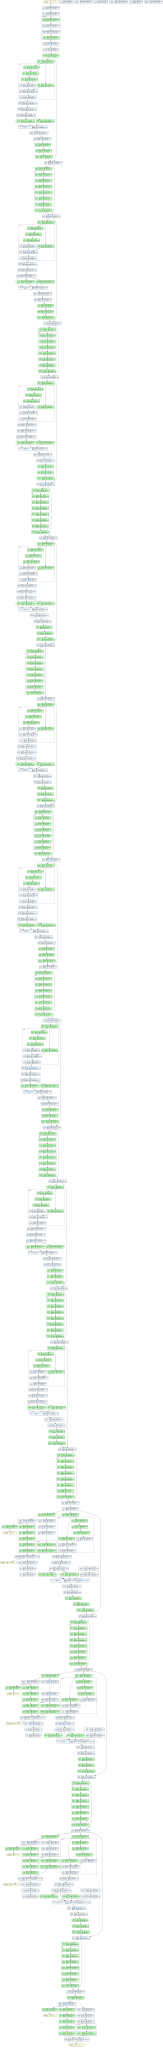

In [ ]:
from torchview import draw_graph
import torch

# Create a dummy input that matches what your model expects (e.g., a batch of 1 image 640x640)
# Depending on MaskClassificationLoRA's exact forward signature, you might need to adjust this.
dummy_input = torch.randn(1, 3, 640, 640).to(device)

# We visualize the underlying network (EoMT) to avoid Lightning wrappers complicating the graph
model1.network.eval()
try:
    model_graph = draw_graph(model1.network, input_size=(1, 3, 640, 640), device=device, expand_nested=True, depth=2)
    display(model_graph.visual_graph)
except Exception as e:
    print(f"Could not draw the graph automatically due to complex forward pass: {e}")
    print("As an alternative, check your Weights & Biases dashboard! WandbLogger automatically logs model topology if configured.")

## Detailed Trainable vs Frozen Parameter Table
Using `torchinfo`, we can generate a deep hierarchical summary that shows the exact parameter counts and their trainability status down to the individual ViT blocks and LoRA layers.

In [ ]:
!pip install torchinfo > /dev/null
from torchinfo import summary

# We set depth=6 to look deep into the ViT encoder blocks and LoRA adapters
model_summary = summary(
    model1.network,
    input_size=(1, 3, 640, 640),
    col_names=("input_size", "output_size", "num_params", "trainable"),
    col_width=18,
    depth=6,
    row_settings=["var_names"]
)

print(model_summary)

Layer (type (var_name))                                                     Input Shape        Output Shape       Param #            Trainable
EoMT (EoMT)                                                                 [1, 3, 640, 640]   [1, 200, 160, 160] 1,386,240          Partial
├─PeftModel (encoder)                                                       --                 --                 (recursive)        Partial
│    └─LoraModel (base_model)                                               --                 --                 (recursive)        Partial
│    │    └─ViT (model)                                                     --                 --                 (recursive)        Partial
│    │    │    └─VisionTransformer (backbone)                               --                 --                 (recursive)        Partial
│    │    │    │    └─PatchEmbed (patch_embed)                              [1, 3, 640, 640]   [1, 1600, 768]     --                 False
│    │    │  

## Inspecting a ViT Block
Let's peek inside the first Transformer block (`blocks[0]`) to see its PyTorch layers and the actual Python code that defines its forward pass.

In [ ]:
import inspect

# Grab the first block from the backbone
block_0 = model1.network.encoder.base_model.model.backbone.blocks[0]

print("=== PyTorch Module Representation ===")
print(block_0)



=== PyTorch Module Representation ===
Block(
  (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (attn): Attention(
    (qkv): lora.Linear(
      (base_layer): Linear(in_features=768, out_features=2304, bias=True)
      (lora_dropout): ModuleDict(
        (default): Dropout(p=0.05, inplace=False)
      )
      (lora_A): ModuleDict(
        (default): Linear(in_features=768, out_features=16, bias=False)
      )
      (lora_B): ModuleDict(
        (default): Linear(in_features=16, out_features=2304, bias=False)
      )
      (lora_embedding_A): ParameterDict()
      (lora_embedding_B): ParameterDict()
      (lora_magnitude_vector): ModuleDict()
    )
    (q_norm): Identity()
    (k_norm): Identity()
    (attn_drop): Dropout(p=0.0, inplace=False)
    (norm): Identity()
    (proj): Linear(in_features=768, out_features=768, bias=True)
    (proj_drop): Dropout(p=0.0, inplace=False)
  )
  (ls1): LayerScale()
  (drop_path1): Identity()
  (norm2): LayerNorm((768,), eps=1e-06, ele